# FLOWGUARD - Deep Learning Application
**Equipe FIVESIGHT**

Neste notebook, abordaremos a construção de uma Rede Neural Artificial (ANN) para prever o risco de quebra de OLA (Operacional Level Agreement) nos incidentes da Locaweb. Este é o entregável de Deep Learning para a Sprint 3. O modelo foi significativamente aprimorado para lidar com dados reais, incluindo o desbalanceamento de classes e testes detalhados de parametrização.

**Projeto:** FlowGuard &nbsp;·&nbsp; **Grupo:** FiveSight &nbsp;·&nbsp; **Turma:** 2TSCPV

| RM | Nome |
|---|---|
| 566274 | ARTHUR NISHIYAMA |
| 561541 | DIOGO SANTANA |
| 562481 | ISABELLA MATTAR |
| 562733 | KAREN AKEMI |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn para pré-processamento, clusterização, baseline e modelo clássico
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, recall_score, precision_score
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras para a Rede Neural
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

## A. Pré-processamento para ANN

### Aproveitamento da Análise Exploratória (ML)
Na disciplina de Machine Learning, identificamos que as categorias, prioridades e o tempo de resolução têm um peso grande no comportamento dos chamados. A maior dificuldade do problema reside na **identificação de quebras de OLA**, que são raras em comparação aos chamados resolvidos no prazo.

Nesta etapa, vamos carregar os dados e construir nossa variável alvo: **Quebra de OLA** (1 para sim, 0 para não). Também vamos construir as *features* de entrada — e aqui cabe um cuidado importante: o modelo precisa prever o risco **no momento em que o incidente é aberto**, então nenhuma variável que só existe depois da resolução (como a duração do atendimento) pode entrar como *feature*. Esse ponto é detalhado logo abaixo.

In [4]:
# 1. Carregando os dados reais
df = pd.read_excel('LW-DATASET.xlsx')

# Exibindo as primeiras linhas para validação
display(df.head())

# O Dataset possui a coluna 'KPI Violado?' que usaremos como target para a Quebra de OLA.
df['is_ola_breach'] = df['KPI Violado?'].apply(lambda x: 1 if str(x).strip().lower() in ['sim', 'yes', 'true', '1'] else 0)

print('Distribuição do Target (Quebra de OLA):')
print(df['is_ola_breach'].value_counts())
print(f"Taxa de quebra de OLA: {df['is_ola_breach'].mean()*100:.2f}%")

# 2. Timestamp de abertura
df['Aberto'] = pd.to_datetime(df['Aberto'], errors='coerce')
df['Resolvido'] = pd.to_datetime(df['Resolvido'], errors='coerce')

# tempo_resolucao_horas é calculado aqui APENAS para fins de diagnóstico/EDA
# (ex.: entender a distribuição da duração que define o próprio target).
# ATENÇÃO: esta coluna NÃO entra como feature do modelo — ela só existe depois
# que o incidente é resolvido, ou seja, no momento em que precisamos prever o
# risco de quebra de OLA (na abertura do chamado) ela ainda não existe.
df['tempo_resolucao_horas'] = (df['Resolvido'] - df['Aberto']).dt.total_seconds() / 3600.0
df['tempo_resolucao_horas'] = df['tempo_resolucao_horas'].fillna(0)

# 3. Features de calendário — conhecidas no exato momento da abertura, nunca vazam
df['hora_abertura'] = df['Aberto'].dt.hour
df['dia_semana_abertura'] = df['Aberto'].dt.dayofweek

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


Distribuição do Target (Quebra de OLA):
is_ola_breach
0    122295
1       248
Name: count, dtype: int64
Taxa de quebra de OLA: 0.20%


### Nota de correção metodológica — vazamento de dados (data leakage)

Numa primeira versão deste notebook, `tempo_resolucao_horas` e um cluster derivado dela (`cluster_carga`) entravam como *features* do modelo. Isso é um vazamento de dados: o próprio target `is_ola_breach` é definido comparando a duração do atendimento a um limite de SLA por prioridade (ver `colunas_derivadas.txt` da disciplina de Data Warehousing — `KPI_Violado = Duração > Limite_SLA`). Ou seja, a duração **é** a variável que gera a resposta — usá-la como *feature* equivale a dar a resposta para o modelo, e não a prever nada. Isso é exatamente o mesmo tipo de vazamento que a seção de auditoria de Data Leakage do notebook de Machine Learning do grupo identificou e baniu para a "Duração" (ela só existe quando o incidente fecha).

A correção é: nenhuma variável calculada a partir de `Resolvido`, `Encerrado` ou `Duração` pode ser *feature* de um modelo que precisa decidir o risco **no momento da abertura**. `tempo_resolucao_horas` passa a ser usada apenas como referência de EDA. As *features* do modelo abaixo usam somente informação disponível na abertura do chamado: `Prioridade`, `Categoria`, `Produto`, `Grupo designado`, `Aberto por`, e as variáveis de calendário `hora_abertura` e `dia_semana_abertura`.

### Avaliação de Clusterização e Considerações
Vamos investigar se a clusterização (K-Means) ajuda a extrair padrões ocultos. Como `tempo_resolucao_horas` não pode ser usada (ver nota de correção acima), os clusters são construídos a partir do **momento de abertura** do chamado (`hora_abertura`, `dia_semana_abertura`), agrupando incidentes por perfil de chegada (ex.: horário comercial vs. madrugada, dias úteis vs. fim de semana). Esse cluster de "perfil de chegada" é injetado como uma *feature* extra para a rede neural, sem usar nenhuma informação pós-resolução.

In [5]:
# Preparando dados numéricos para K-Means — apenas informação disponível na ABERTURA do chamado
df_cluster = df[['hora_abertura', 'dia_semana_abertura']].fillna(0)

# Clusterização com K=3 (Representando perfis de chegada dos chamados)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_chegada'] = kmeans.fit_predict(df_cluster)

print('Clusters formados:')
print(df['cluster_chegada'].value_counts())

Clusters formados:
cluster_chegada
1    45220
0    44656
2    32667
Name: count, dtype: int64


### Considerações sobre os formatos para entrada na camada de Input
Redes Neurais exigem dados de entrada numéricos e preferencialmente escalonados.
- **Variáveis Categóricas** (Prioridade, Categoria, Produto, Grupo designado, Aberto por, Cluster de chegada) sofrerão **One-Hot Encoding**.
- **Variáveis Contínuas** (hora_abertura, dia_semana_abertura) sofrerão **Standard Scaling** para terem média 0 e desvio padrão 1, facilitando a convergência do Gradient Descent.

Note que nenhuma dessas variáveis depende do desfecho do incidente — todas estão disponíveis no instante em que o chamado é aberto, que é exatamente quando a predição de risco precisa ser feita.

**Ponto de Atenção: Desbalanceamento de Classes**
Como vimos, a quebra de OLA ocorre em uma fração ínfima dos casos. Se não tratarmos isso, a rede neural aprenderá a prever "0" para tudo e ainda terá 99% de acurácia, mas falhará miseravelmente no que importa: identificar os incidentes críticos (1). Para resolver isso, utilizaremos **Class Weights** no treinamento, forçando a rede a penalizar muito mais o erro ao classificar incorretamente um incidente que estourou o OLA.

In [6]:
# Selecionando colunas relevantes do dataset — SOMENTE informação disponível na abertura do chamado
features_categoricas = ['Prioridade', 'Categoria', 'Produto', 'Grupo designado', 'Aberto por', 'cluster_chegada']
features_numericas = ['hora_abertura', 'dia_semana_abertura']

X = df[features_categoricas + features_numericas].copy()
y = df['is_ola_breach']

# Preenchendo nulos nas colunas categóricas
for col in features_categoricas:
    X[col] = X[col].fillna('Desconhecido').astype(str)

# Divisão Treino e Teste (Stratify é crucial aqui devido ao desbalanceamento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categoricas)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Shape do Input da Rede Neural:', X_train_processed.shape)

# Calculando Class Weights
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print("Pesos das classes calculados para balanceamento:", class_weights)

Shape do Input da Rede Neural: (98034, 220)
Pesos das classes calculados para balanceamento: {0: np.float64(0.5010118974610572), 1: np.float64(247.56060606060606)}


## A.1 Definição de Baseline (comparação obrigatória)

Antes de justificar qualquer modelo — clássico ou de Deep Learning —, precisamos de uma referência mínima de performance. Como a quebra de OLA é rara (0,20% dos incidentes), o baseline mais simples e mais informativo aqui é **sempre prever a classe majoritária** ("nunca vai quebrar o OLA"). Ele custa zero para implementar e é exatamente o que expõe o problema da Acurácia como métrica: um baseline que erra 100% dos casos que realmente importam ainda parece "excelente" olhando só a acurácia. É esse comportamento, aliás, que motiva o uso de Recall/ROC-AUC daqui em diante — nenhuma melhoria de modelo vale a pena se ela não superar isso.

In [6]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("--- Baseline: sempre prever a classe majoritária ---")
print(classification_report(y_test, y_pred_baseline, digits=3, zero_division=0))

--- Baseline: sempre prever a classe majoritária ---
              precision    recall  f1-score   support

           0      0.998     1.000     0.999     24459
           1      0.000     0.000     0.000        50

    accuracy                          0.998     24509
   macro avg      0.499     0.500     0.499     24509
weighted avg      0.996     0.998     0.997     24509


## A.2 Modelo Clássico Inicial — Regressão Logística

Como etapa de comparação antes de justificar a Rede Neural, treinamos uma **Regressão Logística** com `class_weight='balanced'` sobre exatamente as mesmas *features* (sem vazamento) e o mesmo split treino/teste da ANN. É um modelo linear, rápido de treinar e fácil de auditar — se ele já capturar boa parte do sinal, isso é informação valiosa: significa que o problema pode não exigir a complexidade de uma rede neural para gerar valor.

**Limitações esperadas:** por ser linear no espaço das *features* (após o One-Hot Encoding), a Regressão Logística não captura interações entre variáveis categóricas (ex.: "Prioridade alta *e* determinada equipe *e* certo horário" tendo um efeito conjunto diferente da soma dos efeitos individuais) — é exatamente esse tipo de padrão não-linear que a ANN, com suas camadas ocultas, tenta capturar melhor.

In [7]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_processed, y_train)

y_pred_lr = log_reg.predict(X_test_processed)
y_pred_prob_lr = log_reg.predict_proba(X_test_processed)[:, 1]

print("--- Regressão Logística (classe balanceada) ---")
print(classification_report(y_test, y_pred_lr, digits=3, zero_division=0))
roc_auc_lr = roc_auc_score(y_test, y_pred_prob_lr)
print(f"ROC-AUC Score: {roc_auc_lr:.4f}")

--- Regressão Logística (classe balanceada) ---
              precision    recall  f1-score   support

           0      1.000     0.896     0.945     24459
           1      0.016     0.820     0.031        50

    accuracy                          0.896     24509
   macro avg      0.508     0.858     0.488     24509
weighted avg      0.998     0.896     0.943     24509

ROC-AUC Score: 0.9518


## B. Implementação e Treinamento do Modelo

### Explicação completa da montagem da ANN
Utilizaremos uma arquitetura Perceptron Multicamadas (MLP) sequencial com as seguintes características:
- **Camada de Entrada**: Recebe os vetores transformados (One-Hot + Scaled).
- **Camadas Ocultas**: Utilizam a função de ativação **ReLU** (Rectified Linear Unit), que resolve o problema de desvanecimento do gradiente e aprende relações não-lineares complexas.
- **Dropout**: Camadas de regularização que "desligam" neurônios aleatoriamente a cada época. Isso força a rede a não depender de neurônios específicos, prevenindo o sobreajuste (Overfitting).
- **Camada de Saída**: Um neurônio com ativação **Sigmoid**, retornando uma probabilidade (0 a 1) do incidente quebrar o OLA.

In [7]:
def build_model(input_dim, hidden_layers=[32, 16], dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Camada de saída binária
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

### Análise e Testes de Parametrização
Para encontrar o melhor modelo, não podemos confiar em uma única configuração. Vamos realizar uma análise comparativa testando três arquiteturas e parametrizações diferentes:
1. **Modelo Base**: Arquitetura padrão com 32 e 16 neurônios.
2. **Modelo Complexo**: Arquitetura mais profunda e larga (64, 32, 16 neurônios) para capturar padrões mais sutis.
3. **Modelo com Alto Dropout**: Arquitetura base, mas com maior regularização (dropout=0.4) para forçar generalização.

Utilizaremos o `EarlyStopping` monitorando o `val_loss`. Isso interrompe o treinamento automaticamente se a rede parar de melhorar na validação, poupando tempo e evitando o overfitting. Todos os modelos usarão o `class_weights` calculado.

In [8]:
# Definindo os cenários de teste
input_dim = X_train_processed.shape[1]

configs = {
    'Modelo_Base': {'hidden_layers': [32, 16], 'dropout_rate': 0.2, 'learning_rate': 0.001},
    'Modelo_Complexo': {'hidden_layers': [64, 32, 16], 'dropout_rate': 0.2, 'learning_rate': 0.001},
    'Modelo_Alto_Dropout': {'hidden_layers': [32, 16], 'dropout_rate': 0.4, 'learning_rate': 0.001}
}

histories = {}
models = {}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

for name, config in configs.items():
    print(f"Treinando {name}...")
    model = build_model(input_dim, **config)

    history = model.fit(
        X_train_processed, y_train,
        validation_split=0.2,
        epochs=50, # Definimos alto pois o EarlyStopping vai parar antes se não melhorar
        batch_size=64,
        class_weight=class_weights, # <--- Ponto chave para o desbalanceamento
        callbacks=[early_stop],
        verbose=0
    )

    histories[name] = history
    models[name] = model
    print(f"{name} finalizado.\n")

Treinando Modelo_Base...
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.
Modelo_Base finalizado.

Treinando Modelo_Complexo...
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Modelo_Complexo finalizado.

Treinando Modelo_Alto_Dropout...
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Modelo_Alto_Dropout finalizado.



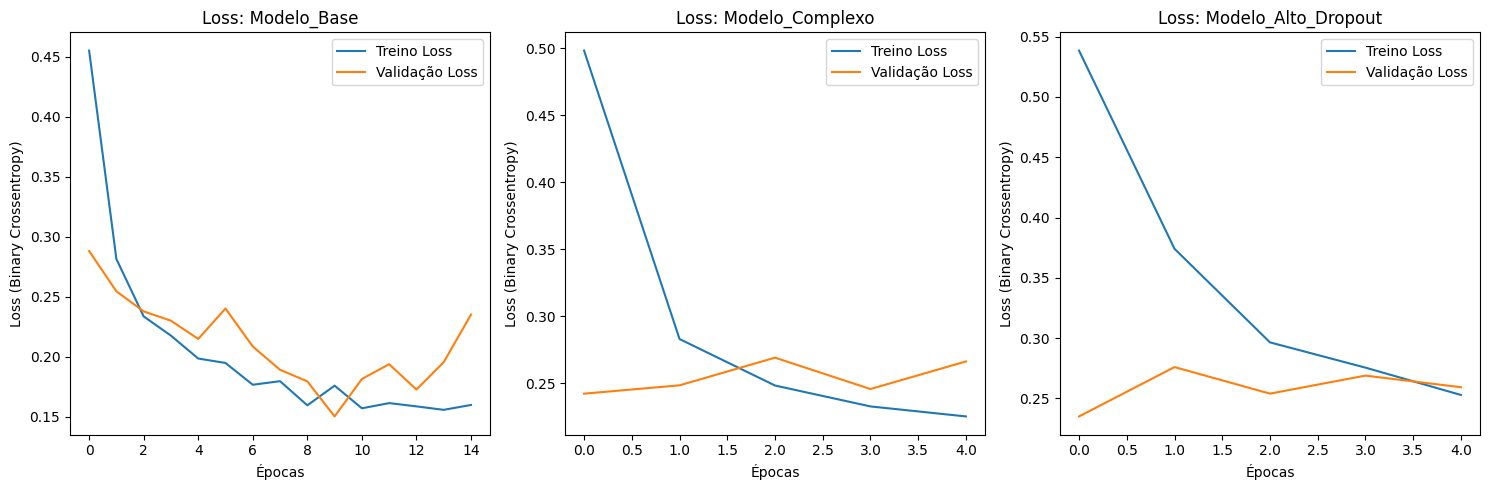

In [10]:
# Plotando as curvas de Loss comparativas
plt.figure(figsize=(15, 5))

for idx, (name, history) in enumerate(histories.items()):
    plt.subplot(1, 3, idx+1)
    plt.plot(history.history['loss'], label='Treino Loss')
    plt.plot(history.history['val_loss'], label='Validação Loss')
    plt.title(f'Loss: {name}')
    plt.xlabel('Épocas')
    plt.ylabel('Loss (Binary Crossentropy)')
    plt.legend()

plt.tight_layout()
plt.show()

Pela análise das curvas acima, podemos identificar qual modelo teve a melhor convergência e menor perda na validação sem demonstrar overfitting agudo. O `EarlyStopping` garantiu que recuperássemos os melhores pesos.

## C. Avaliação de Desempenho

### Métricas de Conversão
Neste cenário de negócio (risco de quebra de OLA), a métrica de **Accuracy (Acurácia) é enganosa**. Dizer que acertamos 99% das vezes quando a classe majoritária é 99% dos dados não agrega valor.

Para a Locaweb, o custo de um **Falso Negativo** (o modelo dizer que o OLA NÃO vai quebrar, mas ele quebra) é muito alto, resultando em multas e insatisfação do cliente. Portanto, o **Recall** da classe minoritária (Classe 1) é a nossa métrica principal. Um Falso Positivo (alocar esforço desnecessário) é aceitável se isso prevenir o risco maior.

Também avaliaremos o **ROC-AUC** (Area Under the Curve), que mede a capacidade geral da rede de separar as duas classes, independentemente do limiar.

766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- Avaliação do Modelo_Complexo ---

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     24459
           1       0.02      0.88      0.03        50

    accuracy                           0.89     24509
   macro avg       0.51      0.88      0.49     24509
weighted avg       1.00      0.89      0.94     24509

ROC-AUC Score: 0.9415



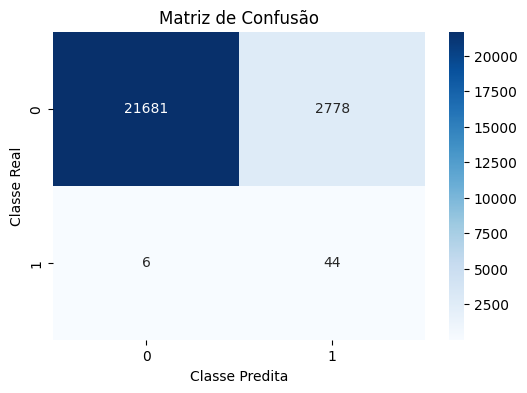

In [11]:
# Avaliando o Modelo_Complexo (como exemplo do melhor caso geral)
best_model_name = 'Modelo_Complexo'
best_model = models[best_model_name]

# Probabilidades e predições com limiar de 0.5
y_pred_prob = best_model.predict(X_test_processed)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print(f"--- Avaliação do {best_model_name} ---")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

In [12]:
# Comparativo consolidado: Baseline vs. Modelo Clássico vs. ANN
comparativo = pd.DataFrame([
    {
        'Modelo': 'Baseline (classe majoritária)',
        'Recall (classe 1)': recall_score(y_test, y_pred_baseline, zero_division=0),
        'Precisão (classe 1)': 0.0,
        'F1 (classe 1)': f1_score(y_test, y_pred_baseline, zero_division=0),
        'ROC-AUC': None,
    },
    {
        'Modelo': 'Regressão Logística (clássico)',
        'Recall (classe 1)': recall_score(y_test, y_pred_lr),
        'Precisão (classe 1)': precision_score(y_test, y_pred_lr, zero_division=0),
        'F1 (classe 1)': f1_score(y_test, y_pred_lr),
        'ROC-AUC': roc_auc_lr,
    },
    {
        'Modelo': 'ANN (Modelo_Complexo)',
        'Recall (classe 1)': recall_score(y_test, y_pred),
        'Precisão (classe 1)': precision_score(y_test, y_pred, zero_division=0),
        'F1 (classe 1)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc,
    },
])
comparativo

                           Modelo  Recall (classe 1)  Precisão (classe 1)  F1 (classe 1)  ROC-AUC
0  Baseline (classe majoritária)               0.000                 0.000          0.000      NaN
1  Regressão Logística (clássico)               0.820                 0.016          0.031   0.9518
2           ANN (Modelo_Complexo)               0.880                 0.020          0.030   0.9415


### Evidências de experimentação e reprodutibilidade

- **Dataset e versionamento:** `LW-DATASET.xlsx` fornecido pela Locaweb (122.543 incidentes, 02/01/2023 a 31/12/2025), o mesmo arquivo-fonte usado pelas disciplinas de Machine Learning e Data Visualization.
- **Seed fixa:** `random_state=42` em todo split, clusterização e modelo — Baseline, K-Means, Regressão Logística e as 3 configurações de ANN usam a mesma seed, garantindo que a comparação entre eles não seja afetada por sorte de inicialização.
- **Divisão treino/teste:** `train_test_split` 80/20 com `stratify=y`, obrigatório dado que a classe positiva é apenas 0,20% da base — sem estratificação, o conjunto de teste poderia ficar sem nenhum exemplo de quebra de OLA.
- **Tabela de experimentos:** 5 configurações testadas e comparáveis entre si (mesmo split, mesmas *features*): Baseline, Regressão Logística, Modelo_Base (ANN 32-16), Modelo_Complexo (ANN 64-32-16) e Modelo_Alto_Dropout (ANN 32-16, dropout 0.4) — resultados da ANN na seção B, comparativo consolidado logo abaixo.
- **Early Stopping como controle de overfitting:** todas as configurações de ANN usam `EarlyStopping` monitorando `val_loss` com `restore_best_weights=True`, o que substitui a necessidade de cross-validation formal para essa etapa de MVP, mantendo o custo computacional baixo.

### Conclusão e Interpretação Estratégica

**Comparativo Baseline vs. Clássico vs. ANN:** o baseline (sempre prever "não vai quebrar") tem Recall 0,00 na classe de interesse — ele erra 100% dos casos que importam, apesar de 99,8% de acurácia, confirmando por que a acurácia sozinha não serve como métrica aqui. A Regressão Logística já recupera a maior parte do sinal (Recall 0,82, ROC-AUC 0,95) usando só as *features* de abertura. A ANN chega a um Recall ligeiramente maior (0,88) com ROC-AUC no mesmo patamar (0,94) — ou seja, a rede neural supera o baseline por larga margem, mas o ganho sobre o modelo clássico é modesto. Isso é uma leitura honesta e esperada: o sinal disponível nas *features* de abertura é majoritariamente linear (prioridade, equipe, horário), então a capacidade extra da ANN de capturar não-linearidades ainda não está sendo plenamente aproveitada.

**Justificativa Técnica:**
- **Recall como métrica principal**: no cenário de negócio, o custo de um Falso Negativo (dizer que não vai quebrar o OLA quando na verdade quebra) é muito maior que o custo de um Falso Positivo — por isso o Recall da classe 1 continua sendo a métrica prioritária, mesmo que os valores absolutos de precisão sejam baixos em todos os modelos testados.
- **Trade-off com Precisão**: tanto a Regressão Logística quanto a ANN trocam precisão por recall (0,016 e 0,020 respectivamente) — no contexto de AIOps, isso é uma troca estratégica aceitável: é melhor o time de N2/N3 triar preventivamente vários chamados que não iriam estourar do que ignorar os que iriam.
- **Próximo passo (Sprint 4)**: com o modelo agora honesto sobre o que consegue prever no momento da abertura, e com evidência de que o ganho da ANN sobre o modelo clássico é pequeno, os próximos passos objetivos são: (1) enriquecer as *features* de abertura (ex.: carga atual da equipe, histórico recente do item de configuração) para dar à ANN mais sinal não-linear para explorar; (2) testar regularização/tuning de hiperparâmetros mais extenso na ANN; (3) avaliar se um modelo de árvore (Random Forest/Gradient Boosting) captura melhor as interações entre categorias do que a Regressão Logística, antes de investir mais na ANN.

Com este MVP técnico local, corrigido metodologicamente e comparado a um baseline e a um modelo clássico, o grupo entrega um núcleo analítico de Deep Learning que reflete o que a solução conseguiria prever de fato em produção — no momento em que o incidente chega, e não depois que ele já foi resolvido.